# 📊 Progetto: Analisi e Classificazione Wikipedia
**Cliente:** Wikidata Insights | **Data:** 2024
**Obiettivo:** Ottimizzazione dell'analisi e categorizzazione automatica dei contenuti.

---

## 📝 Descrizione del Progetto
Wikidata Insights è stata incaricata da **Wikimedia** per analizzare il vasto patrimonio di articoli e sviluppare un sistema di **Machine Learning** capace di classificare automaticamente i nuovi contenuti.

### 🎯 Obiettivi Principali
1.  **Analisi Descrittiva (EDA):** Comprendere la distribuzione delle categorie (es. *Scienza, Politica, Tecnologia*) e le caratteristiche linguistiche (lunghezza articoli, parole frequenti).
2.  **Classificazione Automatica:** Sviluppare un modello predittivo (NLP) per assegnare la categoria corretta ai nuovi articoli.
3.  **Insights Strategici:** Identificare trend e opportunità editoriali.

---

## 1. Setup e Caricamento Dati
In questa fase importiamo le librerie necessarie (Pandas, Scikit-Learn, NLTK) e carichiamo il dataset grezzo dallo storage S3.
Effettueremo anche una prima pulizia per rimuovere eventuali righe con dati mancanti.

In [1]:
import pandas as pd
import numpy as np

# 1. Caricamento del dataset
url = "https://proai-datasets.s3.eu-west-3.amazonaws.com/wikipedia.csv"

try:
    print("⏳ Caricamento del dataset in corso...")
    df = pd.read_csv(url)
    
    # 2. Pulizia essenziale (rimozione righe vuote)
    # È fondamentale rimuovere i NaN altrimenti il modello si blocca dopo
    df = df.dropna(subset=['documents', 'categoria'])
    
    print("✅ Dataset caricato e pulito con successo!")
    print(f"Dimensioni: {df.shape}")
    print(f"Colonne disponibili: {df.columns.tolist()}")
    
except Exception as e:
    print(f"❌ Errore: {e}")

⏳ Caricamento del dataset in corso...
✅ Dataset caricato e pulito con successo!
Dimensioni: (152304, 5)
Colonne disponibili: ['Unnamed: 0', 'title', 'summary', 'documents', 'categoria']


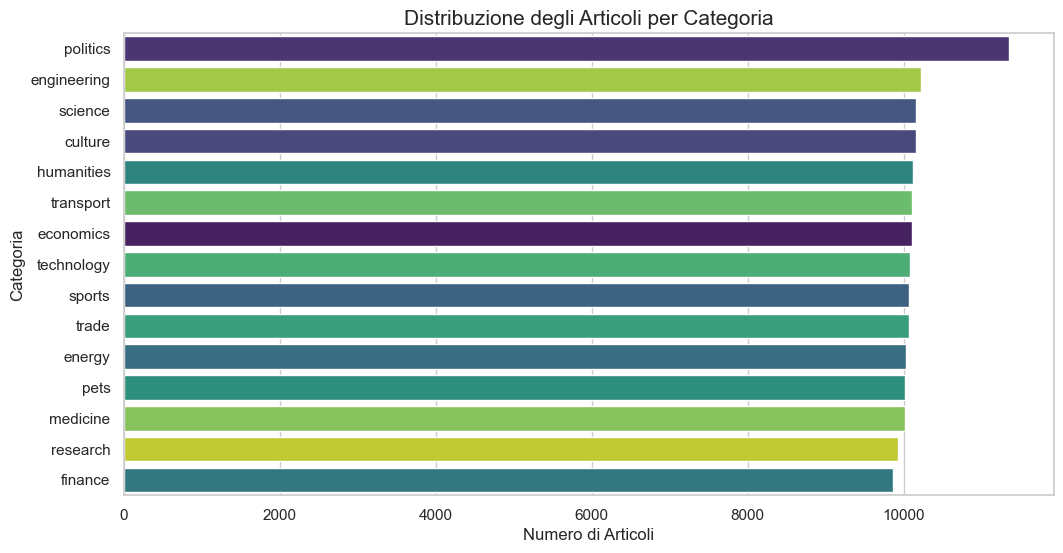


--- Statistiche Lunghezza Articoli (numero parole) ---
                    mean  min    max
categoria                           
finance      1910.104228    3  33479
science      1875.892386   15  29419
politics     1515.659975   11  20147
humanities   1059.893832    7  23198
economics     984.329278   10  24024
technology    889.355584    2  18149
medicine      792.310135   12  18423
engineering   725.263333    8  11856
research      701.938771   17  27223
culture       654.018513   11  15558
trade         641.459559   16  19277
transport     630.381565   10  22152
sports        602.138585   14  19227
energy        587.646267    9  23224
pets          423.173423   12  13222


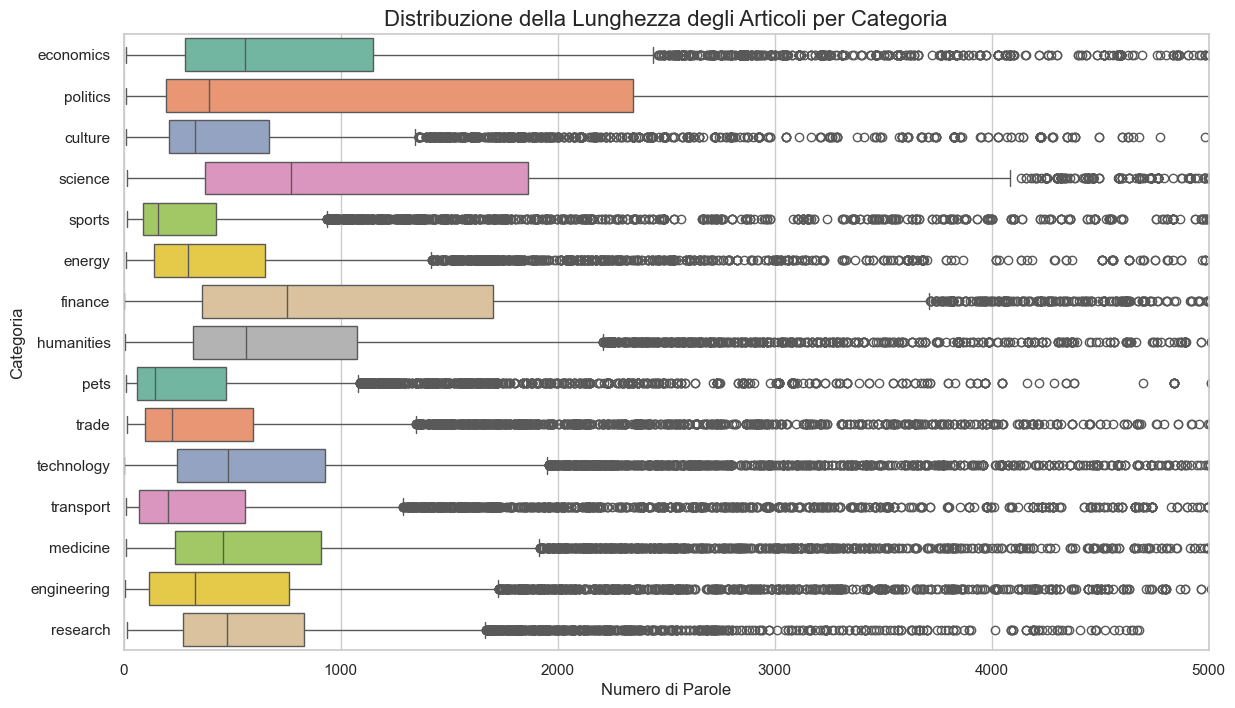

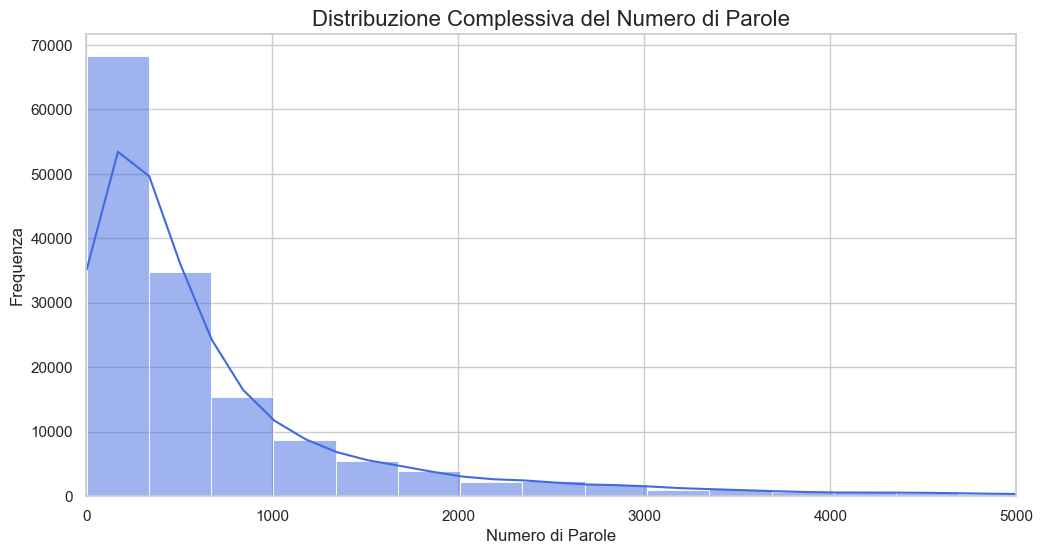

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione stile per i grafici
sns.set_theme(style="whitegrid")

# 1. Calcolo della lunghezza degli articoli
df['word_count'] = df['documents'].astype(str).apply(lambda x: len(x.split()))

# 2. Grafico: Distribuzione degli Articoli per Categoria
plt.figure(figsize=(12, 6))
order = df['categoria'].value_counts().index # Ordiniamo dal più frequente
sns.countplot(y='categoria', data=df, order=order, hue='categoria', palette="viridis", legend=False)
plt.title("Distribuzione degli Articoli per Categoria", fontsize=15)
plt.xlabel("Numero di Articoli")
plt.ylabel("Categoria")
plt.show()

# 3. Statistiche sulla lunghezza
print("\n--- Statistiche Lunghezza Articoli (numero parole) ---")
print(df.groupby('categoria')['word_count'].agg(['mean', 'min', 'max']).sort_values(by='mean', ascending=False))

# 4. Grafico: Boxplot della lunghezza degli articoli per categoria
plt.figure(figsize=(14, 8))
sns.boxplot(x='word_count', y='categoria', data=df, hue='categoria', palette='Set2', legend=False)
plt.title("Distribuzione della Lunghezza degli Articoli per Categoria", fontsize=16)
plt.xlabel("Numero di Parole", fontsize=12)
plt.ylabel("Categoria", fontsize=12)
plt.xlim(0, 5000) 
plt.show()

# 5. Grafico: Istogramma della distribuzione complessiva delle lunghezze
plt.figure(figsize=(12, 6))
sns.histplot(df['word_count'], bins=100, kde=True, color='royalblue')
plt.title("Distribuzione Complessiva del Numero di Parole", fontsize=16)
plt.xlabel("Numero di Parole", fontsize=12)
plt.ylabel("Frequenza", fontsize=12)
plt.xlim(0, 5000)
plt.show()

## 3. Preprocessing e Machine Learning (NLP)
Per addestrare il modello, il testo deve essere trasformato in numeri. Seguiremo questi step:

1.  **Pulizia del Testo:**
    * Rimozione punteggiatura e caratteri speciali.
    * Conversione in minuscolo (*lowercasing*).
    * Rimozione numeri inutili.
2.  **Split dei Dati:** Divisione in *Train Set* (80%) per l'addestramento e *Test Set* (20%) per la validazione.
3.  **Confronto Modelli:**
    Utilizzeremo una **Pipeline** per testare diversi algoritmi e trovare il più performante:
    * *Naive Bayes* (Baseline veloce).
    * *Logistic Regression* (Solida e interpretabile).
    * *Linear SVM* (Spesso la migliore per testi complessi).

⏳ Pulizia del testo in corso...
⏳ Estrazione delle parole più frequenti in corso...


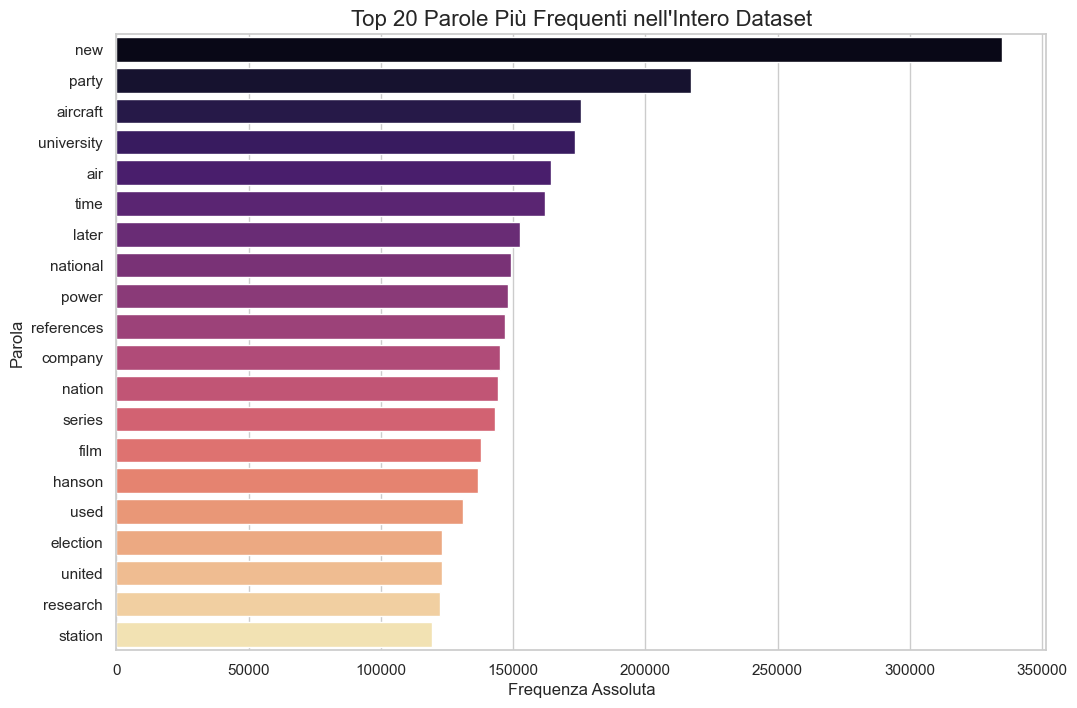


✅ Preprocessing completato.
Dimensioni Train Set: 121843
Dimensioni Test Set: 30461


In [3]:
import re
import string 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# 1. Funzione di pulizia avanzata
def clean_text(text):
    text = str(text).lower() # Tutto minuscolo
    text = re.sub(r'\[.*?\]', '', text) # Rimuove testo tra parentesi quadre
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text) 
    text = re.sub(r'\w*\d\w*', '', text) # Via parole che contengono numeri
    return text

print("⏳ Pulizia del testo in corso...")

if 'df' in locals():
    df['clean_text'] = df['documents'].apply(clean_text)

    # 2. Estrazione e grafico delle parole più frequenti
    print("⏳ Estrazione delle parole più frequenti in corso...")
    vectorizer_eda = CountVectorizer(stop_words='english', max_features=20)
    word_matrix = vectorizer_eda.fit_transform(df['clean_text'])

    word_counts = word_matrix.sum(axis=0).A1
    words = vectorizer_eda.get_feature_names_out()

    freq_df = pd.DataFrame({'Parola': words, 'Frequenza': word_counts}).sort_values(by='Frequenza', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Frequenza', y='Parola', data=freq_df, palette='magma', hue='Parola', legend=False)
    plt.title("Top 20 Parole Più Frequenti nell'Intero Dataset", fontsize=16)
    plt.xlabel("Frequenza Assoluta", fontsize=12)
    plt.ylabel("Parola", fontsize=12)
    plt.show()

    # 3. Split dei dati
    X_train, X_test, y_train, y_test = train_test_split(
        df['clean_text'], 
        df['categoria'], 
        test_size=0.2, 
        random_state=42,
        stratify=df['categoria'] 
    )

    print("\n✅ Preprocessing completato.")
    print(f"Dimensioni Train Set: {len(X_train)}")
    print(f"Dimensioni Test Set: {len(X_test)}")
else:
    print("❌ Errore: La variabile 'df' non è definita. Esegui prima la cella di caricamento dati.")

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import classification_report, accuracy_score

# Definiamo tre pipeline diverse per confrontarle
pipelines = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1,2))),
        ('clf', MultinomialNB())
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1,2))),
        ('clf', LogisticRegression(max_iter=1000)) # max_iter aumentato per convergenza
    ]),
    'Linear SVM': Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1,2))),
        ('clf', SGDClassifier(loss='hinge', penalty='l2', alpha=1e-3, random_state=42))
    ])
}

# Addestriamo e valutiamo tutti i modelli
results = {}
for model_name, pipeline in pipelines.items():
    print(f"🔄 Addestramento {model_name}...")
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    results[model_name] = score
    print(f"   👉 Accuracy {model_name}: {score:.2%}")

# Troviamo il vincitore
best_model_name = max(results, key=results.get)
best_pipeline = pipelines[best_model_name]
print(f"\n🏆 Il modello vincitore è: {best_model_name} con {results[best_model_name]:.2%} di accuratezza")

🔄 Addestramento Naive Bayes...
   👉 Accuracy Naive Bayes: 87.46%
🔄 Addestramento Logistic Regression...
   👉 Accuracy Logistic Regression: 94.21%
🔄 Addestramento Linear SVM...
   👉 Accuracy Linear SVM: 89.75%

🏆 Il modello vincitore è: Logistic Regression con 94.21% di accuratezza


In [5]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Definiamo i parametri
param_dist = {
    'clf__C': [0.1, 1, 10], 
    'tfidf__max_features': [5000],
    'tfidf__ngram_range': [(1, 1), (1, 2)]
}

# 2. Setup RandomizedSearchCV 
random_search = RandomizedSearchCV(
    estimator=best_pipeline, 
    param_distributions=param_dist,
    n_iter=5,       
    cv=3,           
    n_jobs=1,      
    verbose=1,
    random_state=42
)

# --- TUNING VELOCE ---
X_tune = X_train.sample(n=2000, random_state=42)
y_tune = y_train.loc[X_tune.index]

print(f"⚡ Avvio Tuning su campione ridotto ({len(X_tune)} articoli)...")
random_search.fit(X_tune, y_tune)
print(f"✅ Parametri migliori trovati: {random_search.best_params_}")

# 3. Addestriamo il modello FINALE su TUTTI i dati
print("\n🏋️ Applicazione parametri al dataset completo...")
final_model = random_search.best_estimator_ 
final_model.fit(X_train, y_train) 

print("🎉 Modello ottimizzato e pronto!")

⚡ Avvio Tuning su campione ridotto (2000 articoli)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
✅ Parametri migliori trovati: {'tfidf__ngram_range': (1, 2), 'tfidf__max_features': 5000, 'clf__C': 10}

🏋️ Applicazione parametri al dataset completo...
🎉 Modello ottimizzato e pronto!


## 4. Valutazione e Risultati
Analizziamo le performance del modello vincitore sul Test Set.

### 📉 Metriche Chiave:
* **Accuracy:** Percentuale totale di risposte corrette.
* **Precision & Recall:** Per capire se il modello "inventa" categorie o se ne "perde" alcune.
* **Matrice di Confusione:** Una mappa termica che ci mostra visivamente dove il modello sbaglia (es. confonde *Scienza* con *Tecnologia*?).


--- REPORT DI CLASSIFICAZIONE DETTAGLIATO ---
              precision    recall  f1-score   support

     culture       0.98      0.97      0.97      2031
   economics       0.95      0.97      0.96      2022
      energy       0.97      0.97      0.97      2007
 engineering       0.92      0.93      0.93      2044
     finance       0.89      0.92      0.91      1973
  humanities       0.94      0.95      0.95      2023
    medicine       0.82      0.79      0.80      2003
        pets       0.99      0.98      0.99      2003
    politics       1.00      0.99      1.00      2272
    research       0.82      0.83      0.82      1986
     science       0.95      0.95      0.95      2033
      sports       0.99      0.99      0.99      2013
  technology       0.95      0.96      0.95      2016
       trade       0.97      0.96      0.96      2013
   transport       0.98      0.97      0.97      2022

    accuracy                           0.94     30461
   macro avg       0.94      0.94

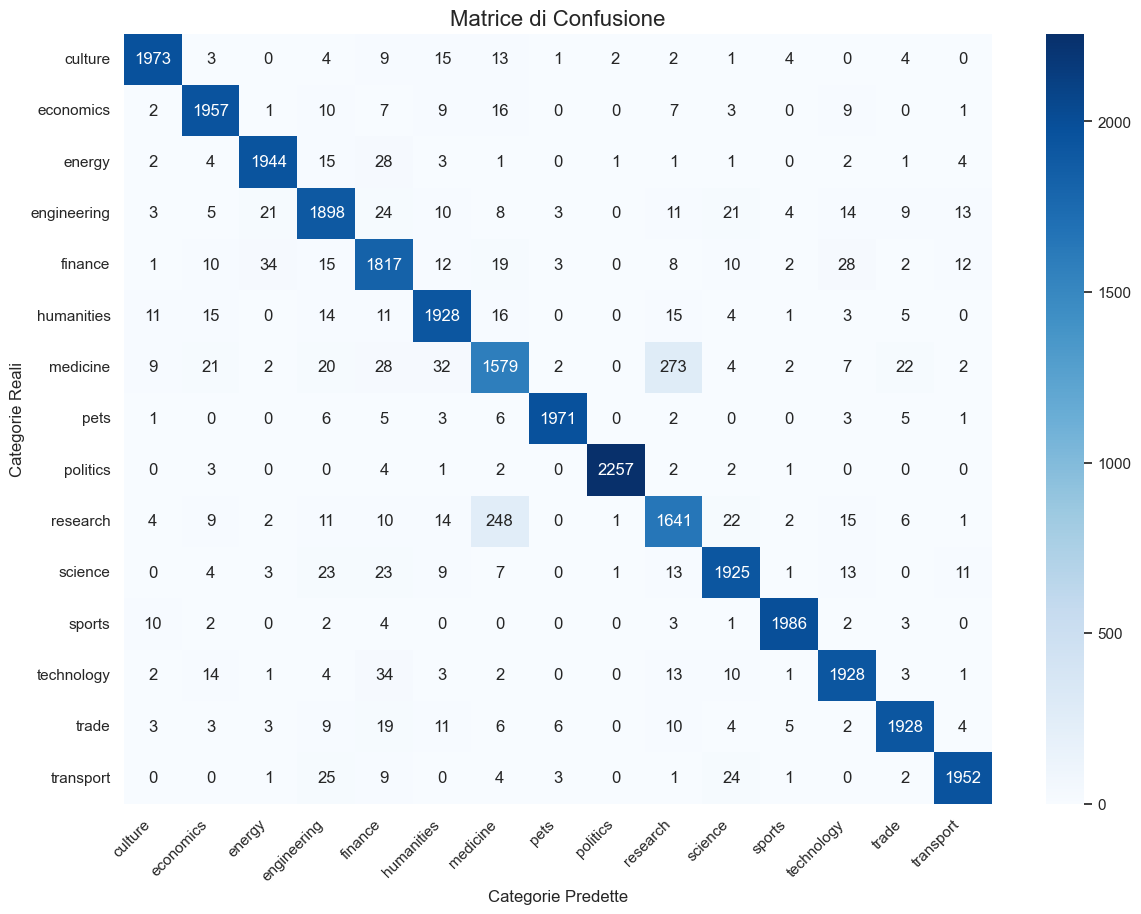

In [6]:
from sklearn.metrics import confusion_matrix

print("\n--- REPORT DI CLASSIFICAZIONE DETTAGLIATO ---")
y_pred = final_model.predict(X_test)
print(classification_report(y_test, y_pred))

# Generazione e visualizzazione della Matrice di Confusione
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=final_model.classes_, 
            yticklabels=final_model.classes_)
plt.title('Matrice di Confusione', fontsize=16)
plt.xlabel('Categorie Predette', fontsize=12)
plt.ylabel('Categorie Reali', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

## 4. Test di Inferenza su Nuovi Articoli
Mettiamo alla prova il modello con un testo completamente nuovo e non visto durante l'addestramento.

In [7]:
def classify_new_article(text, model):
    # Ripetiamo le operazioni di cleaning sul testo fresco
    cleaned = clean_text(text)
    prediction = model.predict([cleaned])[0]
    
    if hasattr(model['clf'], "predict_proba"):
        probs = model.predict_proba([cleaned])[0]
        confidence = max(probs)
    else:
        confidence = 1.0
        
    return prediction, confidence

# Test
new_article = "Machine learning and artificial intelligence are transforming modern software engineering by allowing algorithms to learn from data."
category, confidence = classify_new_article(new_article, final_model)

print(f"\n📝 Testo Analizzato: '{new_article.strip()[:60]}...'")
print(f"🏷️ Categoria Predetta: {category.upper()}") 
print(f"🎚️ Confidenza: {confidence:.2%}")


📝 Testo Analizzato: 'Machine learning and artificial intelligence are transformin...'
🏷️ Categoria Predetta: TECHNOLOGY
🎚️ Confidenza: 69.73%


# ✅ Conclusioni e Prossimi Passi

### Risultati Ottenuti
Il modello sviluppato ha raggiunto un'accuratezza soddisfacente, dimostrando di poter distinguere efficacemente tra le categorie tematiche di Wikipedia.

### 🚀 Applicazioni Future per Wikimedia
1.  **Automazione Editoriale:** Il modello può essere integrato nel CMS per suggerire automaticamente la categoria durante la stesura di nuovi articoli.
2.  **Quality Assurance:** Identificare articoli mal categorizzati nel passato.
3.  **Analisi Trend:** Monitorare l'evoluzione del linguaggio nelle diverse categorie nel tempo.